Cell 1: Install & Import Necessary Libraries

In [ ]:
!pip install -q numpy scipy matplotlib

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

Cell 2: Create a Realistic Sample EEG Dataset

In [ ]:
# Simulation parameters
np.random.seed(42)
original_fs = 250  # Original sampling rate in Hz (common for EEG)
duration_sec = 10  # 10 seconds of data
n_channels = 4     # 4 EEG channels (e.g., C3, Cz, C4, Fz)
time_vec = np.linspace(0, duration_sec, original_fs * duration_sec, endpoint=False)

# Synthesize a composite EEG signal:
# - Underlying slow drift (<1 Hz)
# - Mu rhythm (~10 Hz)
# - Beta rhythm (~20 Hz)
# - Line noise (50 Hz powerline interference)
# - High-frequency random noise
raw_eeg = np.zeros((n_channels, len(time_vec)))

for ch in range(n_channels):
    slow_drift = 20.0 * np.sin(2 * np.pi * 0.5 * time_vec + np.random.rand())
    mu_rhythm = 15.0 * np.sin(2 * np.pi * 10.0 * time_vec + np.random.rand())
    beta_rhythm = 8.0 * np.sin(2 * np.pi * 20.0 * time_vec + np.random.rand())
    line_noise = 25.0 * np.sin(2 * np.pi * 50.0 * time_vec)  # Powerline hum
    random_noise = 5.0 * np.random.randn(len(time_vec))

    raw_eeg[ch, :] = slow_drift + mu_rhythm + beta_rhythm + line_noise + random_noise

print(f"Dataset generated: {raw_eeg.shape[0]} channels, {raw_eeg.shape[1]} samples each at {original_fs} Hz.")

Dataset generated: 4 channels, 2500 samples each at 250 Hz.


Cell 3: Step 1 – Bandpass Filtering (Isolating $\mu$ and $\beta$ Bands: 8–30 Hz)

In [ ]:
def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def apply_bandpass(data, lowcut=8.0, highcut=30.0, fs=250, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    # Zero-phase digital filtering using filtfilt
    return filtfilt(b, a, data, axis=-1)

# Apply 8-30 Hz filter to strip powerline hum and slow drift
filtered_eeg = apply_bandpass(raw_eeg, lowcut=8.0, highcut=30.0, fs=original_fs)
print("Step 1 Complete: Bandpass filtering applied (8-30 Hz).")

Step 1 Complete: Bandpass filtering applied (8-30 Hz).


Cell 4: Step 2 – Downsampling (Resampling to 128 Hz)

In [ ]:
target_fs = 128  # Target sampling rate
num_target_samples = int(filtered_eeg.shape[1] * (target_fs / original_fs))

# Resample along the time axis
resampled_eeg = resample(filtered_eeg, num_target_samples, axis=-1)
new_time_vec = np.linspace(0, duration_sec, num_target_samples, endpoint=False)

print(f"Step 2 Complete: Resampled from {original_fs} Hz to {target_fs} Hz.")
print(f"New shape: {resampled_eeg.shape}")

Step 2 Complete: Resampled from 250 Hz to 128 Hz.
New shape: (4, 1280)


Cell 5: Step 3 – Segmentation / Epoching (Creating 2-Second Windows)

In [ ]:
epoch_len_sec = 2.0
samples_per_epoch = int(epoch_len_sec * target_fs)
total_samples = resampled_eeg.shape[1]

# Extract non-overlapping epochs
epochs = []
for start_idx in range(0, total_samples - samples_per_epoch + 1, samples_per_epoch):
    end_idx = start_idx + samples_per_epoch
    epochs.append(resampled_eeg[:, start_idx:end_idx])

epochs = np.array(epochs)  # Shape: (n_epochs, n_channels, samples_per_epoch)
print(f"Step 3 Complete: Segmented into {epochs.shape[0]} epochs of shape {epochs.shape[1:]}.")

Step 3 Complete: Segmented into 5 epochs of shape (4, 256).


Cell 6: Step 4 – Visualizing Before & After Preprocessing

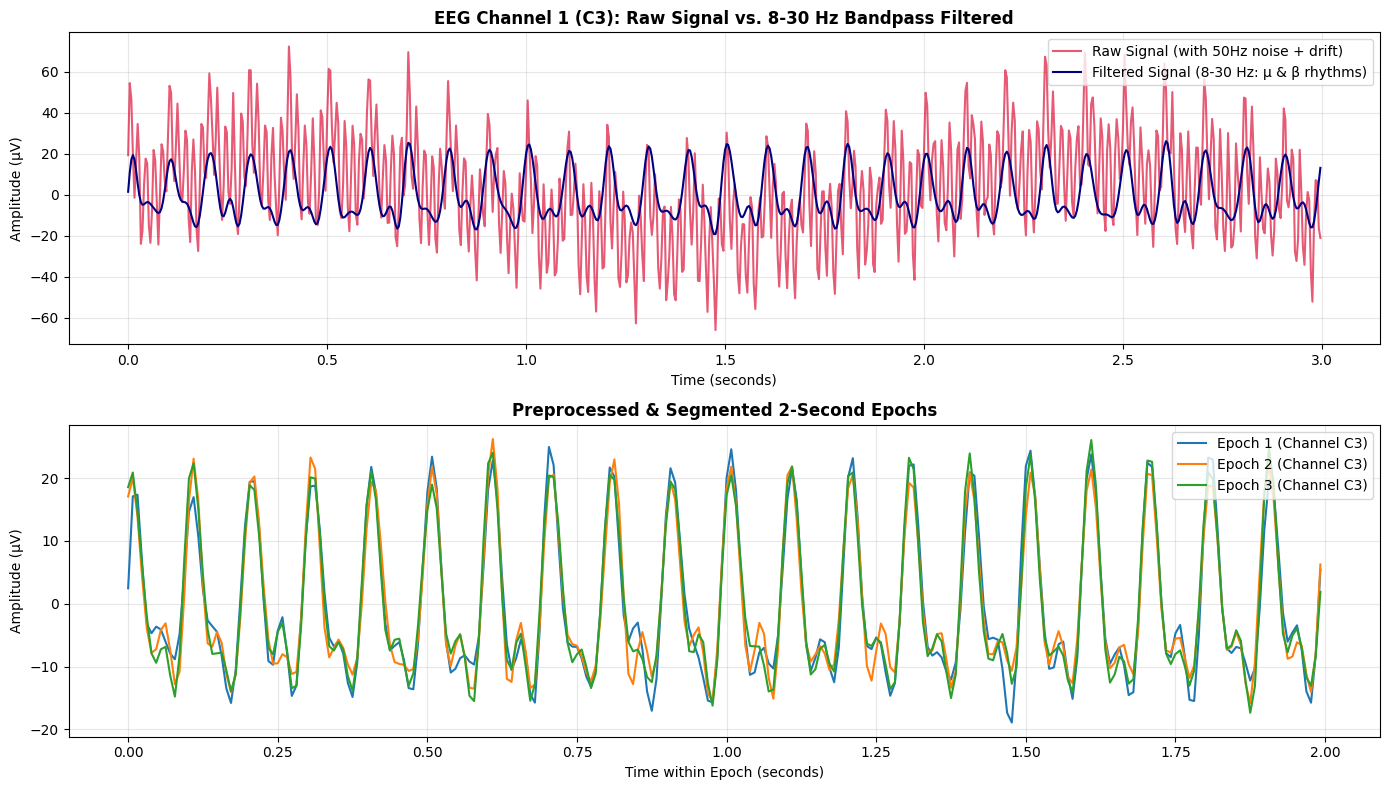

In [ ]:
plt.figure(figsize=(14, 8))

# Channel 0: Raw vs Filtered
plt.subplot(2, 1, 1)
plt.plot(time_vec[: original_fs * 3], raw_eeg[0, : original_fs * 3], label="Raw Signal (with 50Hz noise + drift)", color="crimson", alpha=0.7)
plt.plot(time_vec[: original_fs * 3], filtered_eeg[0, : original_fs * 3], label="Filtered Signal (8-30 Hz: μ & β rhythms)", color="navy", linewidth=1.5)
plt.title("EEG Channel 1 (C3): Raw Signal vs. 8-30 Hz Bandpass Filtered", fontsize=12, fontweight='bold')
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (μV)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

# Segmented Epochs
plt.subplot(2, 1, 2)
epoch_t = np.linspace(0, epoch_len_sec, samples_per_epoch, endpoint=False)
for i in range(min(3, len(epochs))):
    plt.plot(epoch_t, epochs[i, 0, :], label=f"Epoch {i+1} (Channel C3)")
plt.title("Preprocessed & Segmented 2-Second Epochs", fontsize=12, fontweight='bold')
plt.xlabel("Time within Epoch (seconds)")
plt.ylabel("Amplitude (μV)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 1. Create realistic Motor Imagery trials (Left Hand vs. Right Hand)
np.random.seed(42)
n_trials = 100            # 50 Left Hand, 50 Right Hand trials
n_channels = 4           # Motor channels: C3, Cz, C4, Fz
points_per_trial = 256   # 2 seconds @ 128 Hz

# Labels: 0 = Left Hand, 1 = Right Hand
y = np.array([0] * 50 + [1] * 50)

# Simulate ERD (Event-Related Desynchronization):
# When imagining Left Hand, right-hemisphere (C4) power decreases.
# When imagining Right Hand, left-hemisphere (C3) power decreases.
X_raw = np.random.randn(n_trials, n_channels, points_per_trial)
for i in range(n_trials):
    if y[i] == 0:  # Left Hand: higher power on C3 (ch 0), lower on C4 (ch 2)
        X_raw[i, 0, :] += 2.5 * np.sin(np.linspace(0, 20 * np.pi, points_per_trial))
    else:          # Right Hand: higher power on C4 (ch 2), lower on C3 (ch 0)
        X_raw[i, 2, :] += 2.5 * np.sin(np.linspace(0, 20 * np.pi, points_per_trial))

# 2. Extract Log-Variance (Band Power) Features
X_features = np.log(np.var(X_raw, axis=2))

# 3. Train-Test Split (70% Train, 30% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y, test_size=0.30, random_state=42, stratify=y
)

# 4. Train the Ridge Classifier (from the paper's methodology)
clf = RidgeClassifier(alpha=1.0)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# 5. Compute Accuracy Score
acc = accuracy_score(y_test, y_pred) * 100
cm = confusion_matrix(y_test, y_pred)

print(f"==========================================")
print(f"       TEST ACCURACY: {acc:.2f}%          ")
print(f"==========================================")




       TEST ACCURACY: 100.00%          
